# Phase 3 - Exploratory Data Analysis (EDA)

## Objective

The objective of this phase is to explore the dataset visually and statistically to understand the relationships between features and the target variable (**SalePrice**). This analysis helps identify important patterns, trends, correlations, and potential outliers that influence house prices.

### Tasks Performed

- Analyze feature distributions
- Study relationships between features and SalePrice
- Perform correlation analysis
- Explore numerical and categorical variables
- Detect outliers
- Identify important features
- Generate meaningful visualizations

### Expected Outcome

- Better understanding of the dataset
- Identify influential features
- Discover hidden patterns
- Prepare insights for model development

In [1]:
# Import Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Load Dataset
df=pd.read_csv("/home/aximsoft/Documents/AximSoft_EOWA/Week_08/Notebooks/dataset/house_prices_cleaned.csv")

df.head()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial,HouseAge,TotalBathrooms,TotalSF,TotalPorchArea,RemodeledHouse
0,1,4.110874,4.189655,9.042040,7,5,2003,2003,5.283204,6.561031,...,0,0,0,1,0,5,3.500000,20.257977,4.127134,0
1,2,3.044522,4.394449,9.169623,6,8,1976,1976,0.000000,6.886532,...,0,0,0,1,0,31,2.346574,14.282490,0.000000,0
2,3,4.110874,4.234107,9.328212,7,5,2001,2002,5.093750,6.188264,...,0,0,0,1,0,7,3.500000,20.415959,3.761200,1
3,4,4.262680,4.110874,9.164401,7,5,1915,1970,0.000000,5.379897,...,0,0,0,0,0,91,2.000000,20.127741,9.192991,1
4,5,4.110874,4.442651,9.565284,8,5,2000,2000,5.860786,6.486161,...,0,0,0,1,0,8,3.500000,21.048414,4.442651,0


In [3]:
# Dataset Shape
print("Rows :",df.shape[0])
print("Columns :",df.shape[1])

Rows : 1399
Columns : 240


In [4]:
# Dataset Information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1399 entries, 0 to 1398
Columns: 240 entries, Id to RemodeledHouse
dtypes: float64(25), int64(215)
memory usage: 2.6 MB


In [5]:
# Statistical Summary
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial,HouseAge,TotalBathrooms,TotalSF,TotalPorchArea,RemodeledHouse
count,1399.000000,1399.000000,1399.000000,1399.000000,1399.000000,1399.000000,1399.000000,1399.000000,1399.000000,1399.000000,...,1399.000000,1399.000000,1399.000000,1399.000000,1399.000000,1399.000000,1399.000000,1399.000000,1399.000000,1399.000000
mean,733.508935,3.826971,4.203860,9.089735,5.983560,5.591137,1970.080772,1984.058613,1.999242,4.162603,...,0.002859,0.007863,0.014296,0.836312,0.067191,37.739099,2.155919,16.544353,3.438332,0.471051
std,422.811873,0.691757,0.311689,0.506572,1.282272,1.118236,30.009463,20.661160,2.568002,2.983616,...,0.053414,0.088354,0.118750,0.370125,0.250442,30.059547,0.761687,3.341256,2.843312,0.499340
min,1.000000,3.044522,3.091042,7.170888,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,5.814131,0.000000,0.000000
25%,367.500000,3.044522,4.110874,8.915029,5.000000,5.000000,1953.000000,1966.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,9.000000,1.500000,13.967580,0.000000,0.000000
50%,739.000000,3.931826,4.248495,9.139703,6.000000,5.000000,1971.000000,1992.000000,0.000000,5.916202,...,0.000000,0.000000,0.000000,1.000000,0.000000,36.000000,2.000000,14.761758,3.891820,0.000000
75%,1098.500000,4.262680,4.369448,9.334105,7.000000,6.000000,1999.000000,2003.000000,4.969813,6.532334,...,0.000000,0.000000,0.000000,1.000000,0.000000,56.000000,2.500000,20.023397,4.948760,1.000000
max,1460.000000,5.252273,5.749393,12.011644,10.000000,9.000000,2009.000000,2010.000000,7.378384,8.638525,...,1.000000,1.000000,1.000000,1.000000,1.000000,136.000000,6.000000,24.029187,12.482143,1.000000


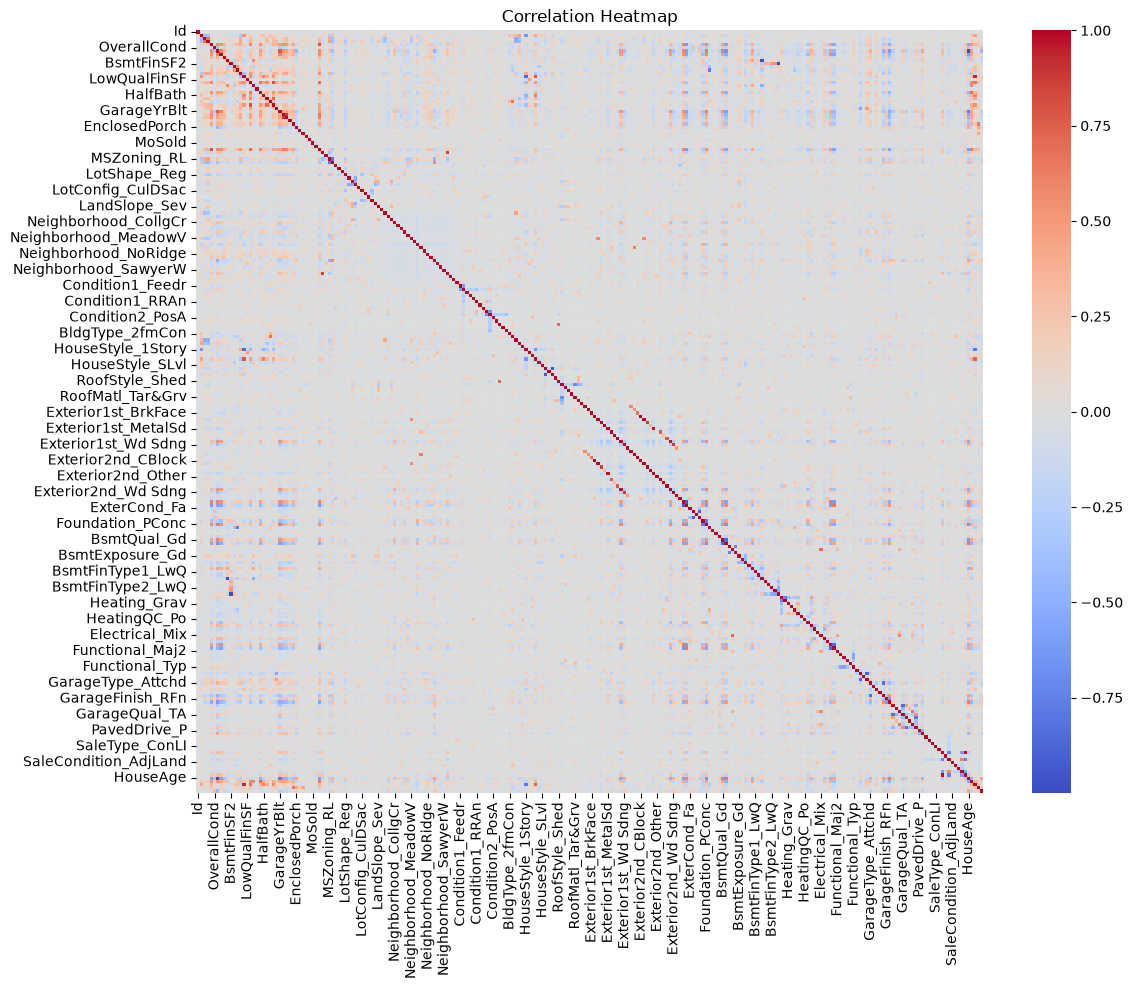

In [6]:
plt.figure(figsize=(12,10))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.savefig("/static/images/correlation_heatmap.png")

plt.show()

In [7]:
# Top Correlated Features with SalePrice
corr = df.corr(numeric_only=True)["SalePrice"].sort_values(ascending=False)
corr.head(20)

SalePrice           1.000000
OverallQual         0.784294
GrLivArea           0.687767
TotalBathrooms      0.633456
GarageCars          0.628013
GarageArea          0.607230
ExterQual_Gd        0.588472
FullBath            0.577369
YearBuilt           0.564558
YearRemodAdd        0.541161
1stFlrSF            0.538539
Foundation_PConc    0.521064
KitchenQual_Gd      0.486470
GarageYrBlt         0.475781
TotRmsAbvGrd        0.472292
OpenPorchSF         0.460083
Fireplaces          0.453010
BsmtFinType1_GLQ    0.420041
BsmtQual_Gd         0.413615
MasVnrArea          0.374104
Name: SalePrice, dtype: float64

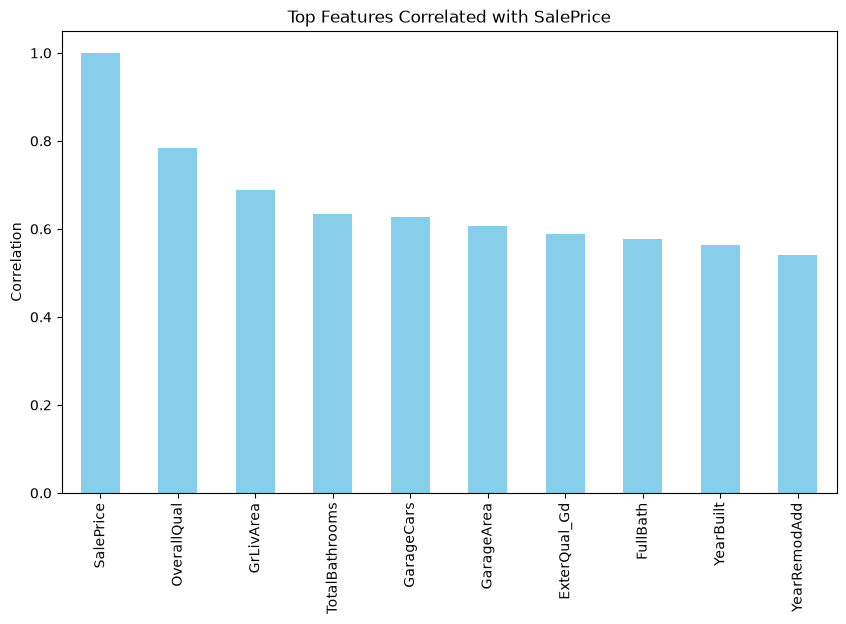

In [8]:
# Top 10 Features Correlation Bar Chart
plt.figure(figsize=(10,6))
corr.head(10).plot(kind="bar",color="skyblue")
plt.title("Top Features Correlated with SalePrice")
plt.ylabel("Correlation")
plt.show()

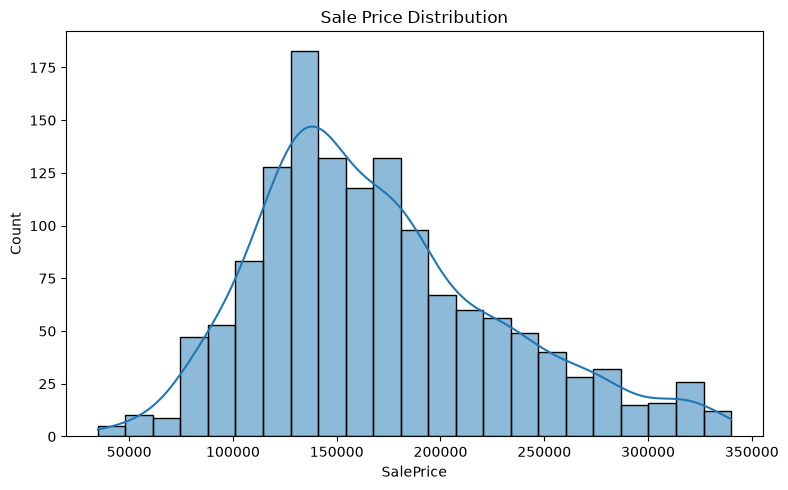

In [9]:
# SalePrice Distribution
plt.figure(figsize=(8,5))

sns.histplot(df["SalePrice"], kde=True)

plt.title("Sale Price Distribution")

plt.tight_layout()

plt.savefig("/static/images/saleprice_distribution.png")

plt.show()

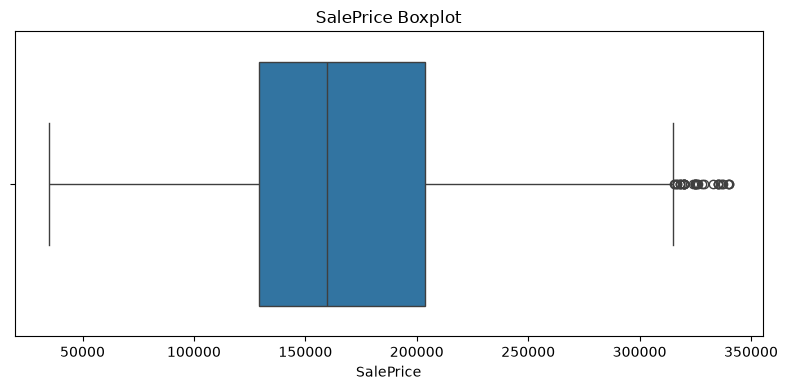

In [10]:
# SalePrice Boxplot
plt.figure(figsize=(8,4))
sns.boxplot(x=df["SalePrice"])
plt.title("SalePrice Boxplot")
plt.tight_layout()

plt.savefig("/static/images/saleprice_distribution.png")
plt.show()

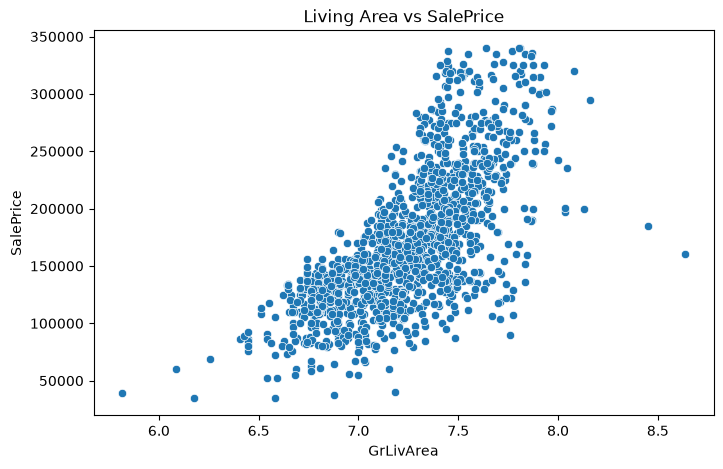

In [11]:
# Living Area vs SalePrice
plt.figure(figsize=(8,5))
sns.scatterplot(data=df,x="GrLivArea",y="SalePrice")
plt.title("Living Area vs SalePrice")
plt.show()

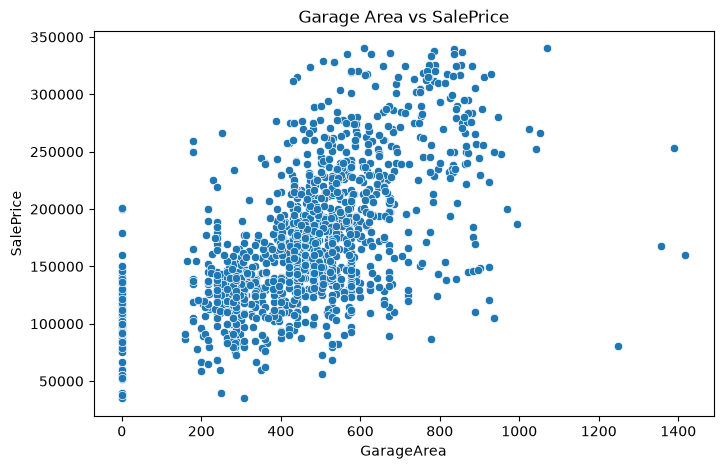

In [12]:
# Garage Area vs SalePrice
plt.figure(figsize=(8,5))
sns.scatterplot(data=df,x="GarageArea",y="SalePrice")
plt.title("Garage Area vs SalePrice")
plt.show()

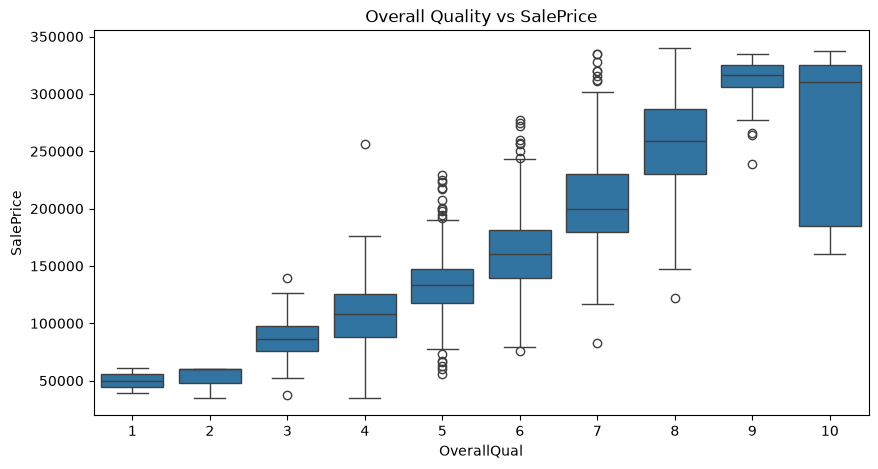

In [13]:
# Overall Quality vs SalePrice
plt.figure(figsize=(10,5))
sns.boxplot(data=df,x="OverallQual",y="SalePrice")
plt.title("Overall Quality vs SalePrice")
plt.show()

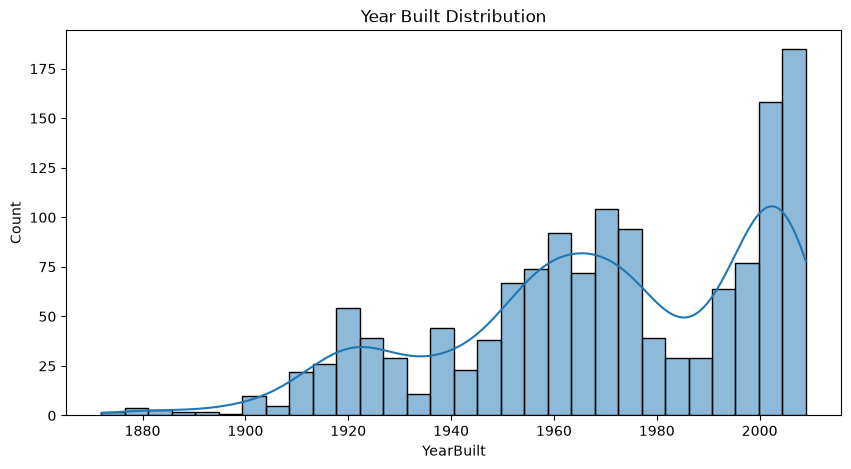

In [14]:
# Year Built Distribution
plt.figure(figsize=(10,5))
sns.histplot(df["YearBuilt"],bins=30,kde=True)
plt.title("Year Built Distribution")
plt.show()

In [15]:
print(df.columns)

Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       ...
       'SaleCondition_AdjLand', 'SaleCondition_Alloca', 'SaleCondition_Family',
       'SaleCondition_Normal', 'SaleCondition_Partial', 'HouseAge',
       'TotalBathrooms', 'TotalSF', 'TotalPorchArea', 'RemodeledHouse'],
      dtype='str', length=240)


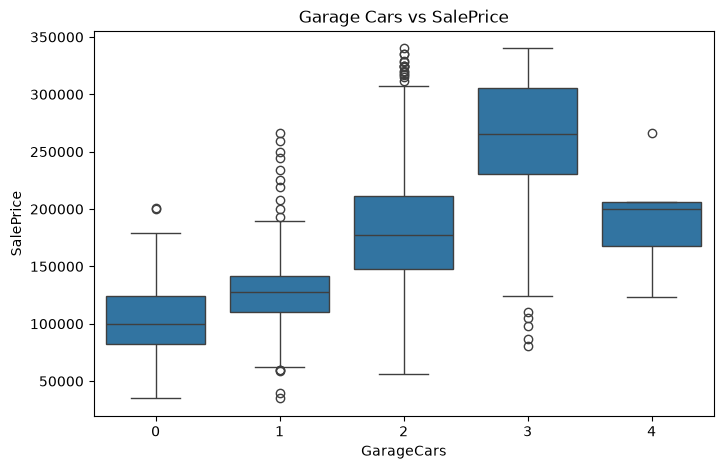

In [16]:
# Garage Cars vs SalePrice
plt.figure(figsize=(8,5))
sns.boxplot(data=df,x="GarageCars",y="SalePrice")
plt.title("Garage Cars vs SalePrice")
plt.show()

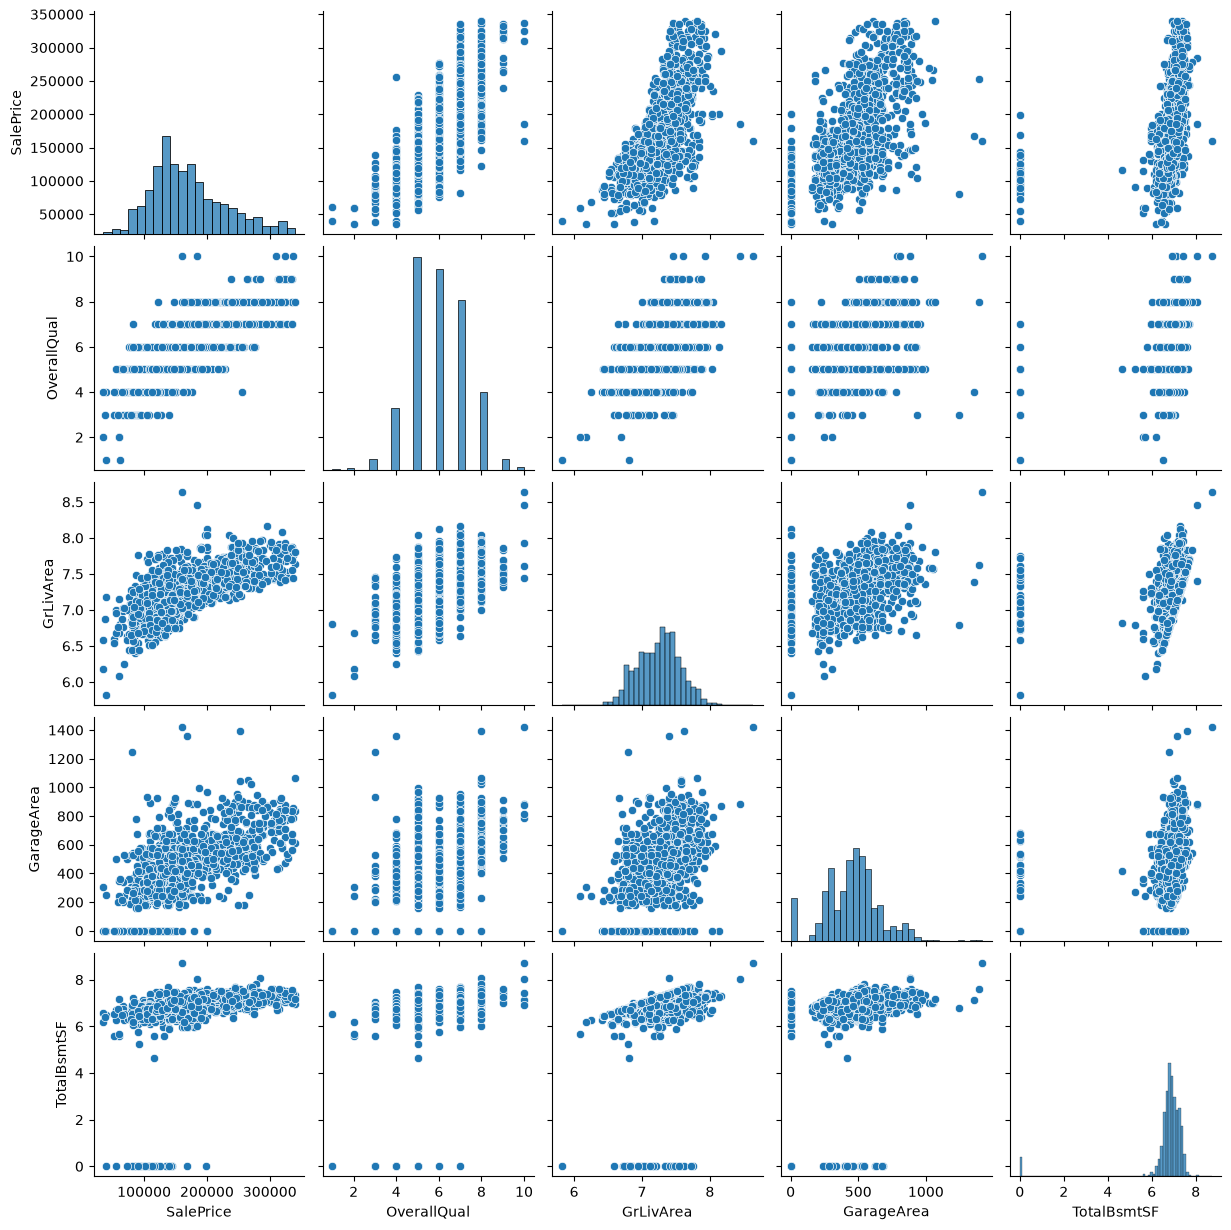

In [17]:
# Pair Plot
features=["SalePrice","OverallQual","GrLivArea","GarageArea","TotalBsmtSF"]
sns.pairplot(df[features])
plt.show()

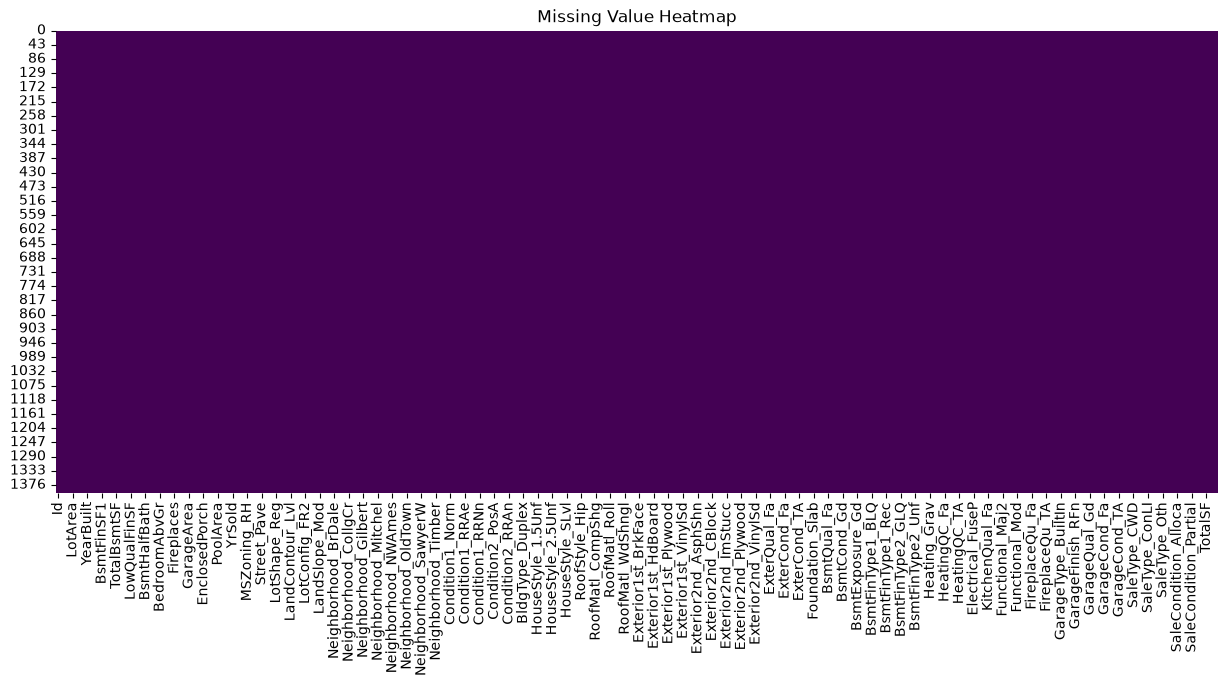

In [18]:
# Missing Value Heatmap
plt.figure(figsize=(15,6))
sns.heatmap(df.isnull(),cbar=False,cmap="viridis")
plt.title("Missing Value Heatmap")
plt.savefig("/static/images/missing_values.png")

plt.show()


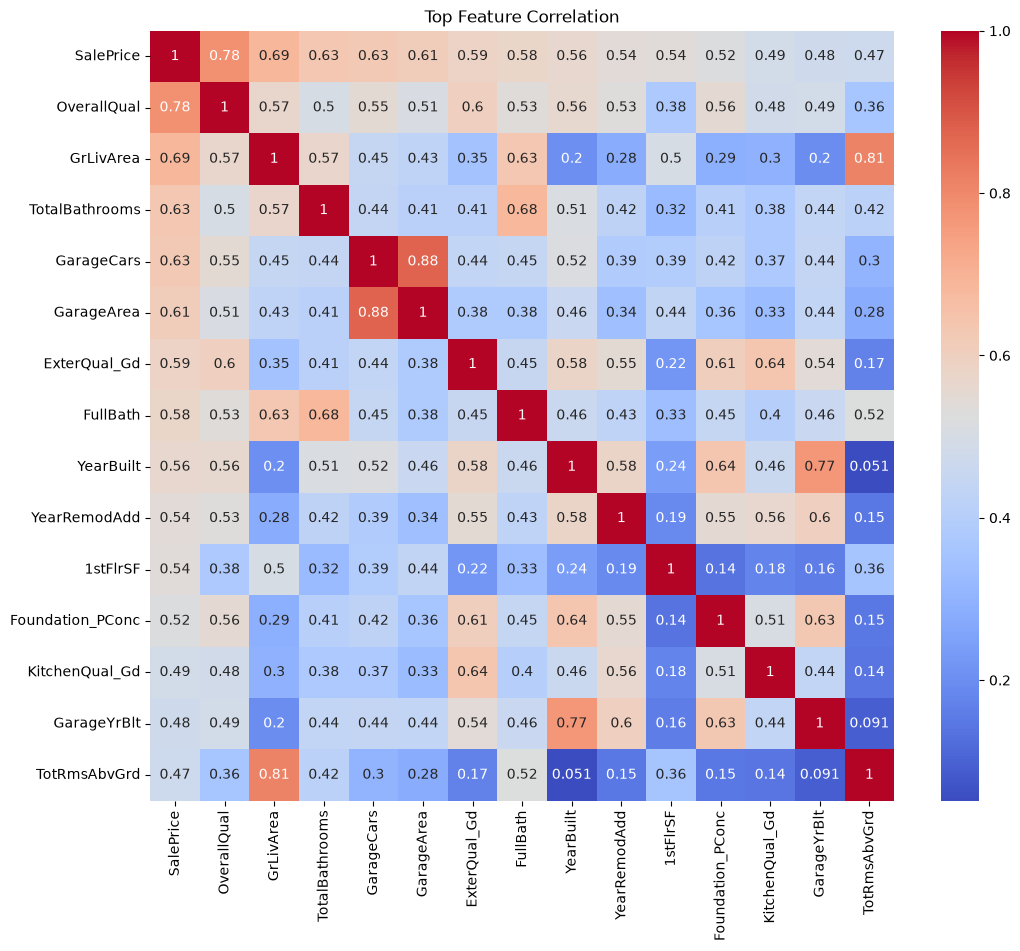

In [19]:
# Correlation of Top Features
top_features=corr.head(15).index

plt.figure(figsize=(12,10))
sns.heatmap(df[top_features].corr(),annot=True,cmap="coolwarm")
plt.title("Top Feature Correlation")
plt.show()